# TP1 — Part 3: CNNs + Data Augmentation on MNIST (Rotation & Translation)

**Course:** Deep Learning for Image Analysis / Computer Vision  
**Goal:** Train a **CNN** on MNIST, **inspect its layers**, and show how **data augmentation** (rotation + translation) can improve robustness.

In Part 2, we used an MLP and **flattened** images into vectors.  
In Part 3, we use **CNNs** to exploit spatial structure **(1, 28, 28)** and we test a key idea in vision:  
> If we train with rotated/translated images, the model generalizes better to these transformations.

---
## What you will do
1. Train a baseline CNN on MNIST (no augmentation)
2. Train the same CNN with **RandomAffine** augmentation (rotation + translation)
3. Compare test accuracy on:
   - **standard MNIST test**
   - **transformed MNIST test** (rotated/translated)
---


## 0) Setup (Colab GPU)

In Colab: **Runtime → Change runtime type → GPU**  
Then run the cell below.


In [1]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Using device: cpu


## 1) Imports

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import datasets
import torchvision.transforms as transforms

import matplotlib.pyplot as plt


## 2) Data: MNIST + Augmentations

We will create **four** dataset variants:

1. **Train (no aug)**: standard MNIST training set  
2. **Train (aug)**: MNIST with *rotation + translation* 
3. **Test (standard)**: standard MNIST test set  
4. **Test (transformed)**: MNIST test set **with the same types of transforms** (to evaluate robustness)

### Augmentation used
- Rotation: up to ±35 degrees
- Translation: up to 30% of the image size

This simulates real-world variation (digits rarely appear perfectly centered).


In [6]:
torch.manual_seed(0)

# Standard transform
tfm_standard = transforms.ToTensor()

# Augmentation: rotation + translation (applied during training)
tfm_aug = transforms.Compose([
   # Todo tansformations to be applied
   #Todo think of using RandomAffine
   transforms.RandomAffine(degrees=35, translate=(0.3, 0.3)),
   transforms.ToTensor()
])

# "Transformed test" to measure robustness to these changes
tfm_test_transformed = transforms.Compose([
    #Todo same transformations as above
    transforms.RandomAffine(degrees=35, translate=(0.3, 0.3)),
    transforms.ToTensor()
])

# Datasets
data_path = './data'
train_noaug  = datasets.MNIST(root=data_path, train=True, download=True, transform=tfm_standard)
train_aug   = datasets.MNIST(root=data_path, train=True, download=True, transform=tfm_aug)

test_std    = datasets.MNIST(root=data_path, train=False, download=True, transform=tfm_standard)
test_trans  = datasets.MNIST(root=data_path, train=False, download=True, transform=tfm_test_transformed)

len(train_noaug), len(train_aug), len(test_std), len(test_trans)


(60000, 60000, 10000, 10000)

### Quick visualization (standard vs augmented)

If augmentation is working, you should see digits slightly rotated and shifted.


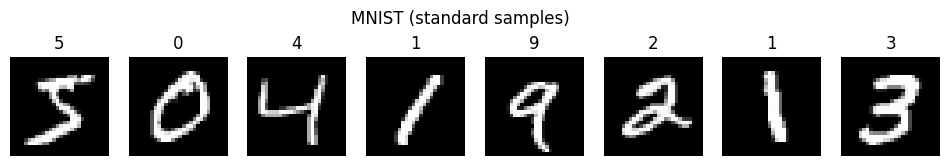

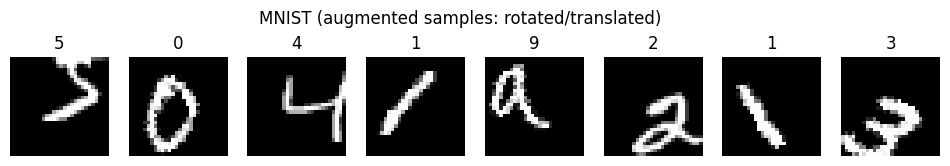

In [7]:
def show_samples(dataset, title, n=8):
    plt.figure(figsize=(12, 2))
    for i in range(n):
        img, label = dataset[i]
        plt.subplot(1, n, i+1)
        plt.imshow(img.squeeze(0), cmap="gray")
        plt.title(str(label))
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

show_samples(train_noaug, "MNIST (standard samples)")
show_samples(train_aug, "MNIST (augmented samples: rotated/translated)")


## 3) DataLoaders

We'll use mini-batches. If you run out of memory, reduce `batch_size`.


In [8]:
batch_size = 128

train_loader_noaug = DataLoader(train_noaug, batch_size=batch_size, shuffle=True)
train_loader_aug   = DataLoader(train_aug, batch_size=batch_size, shuffle=True)

test_loader_std    = DataLoader(test_std, batch_size=batch_size, shuffle=False)
test_loader_trans  = DataLoader(test_trans, batch_size=batch_size, shuffle=False)


## 4) CNN model

A simple CNN for MNIST:

- Conv(1→16) + ReLU + MaxPool
- Conv(16→32) + ReLU + MaxPool
- Flatten
- FC(32×7×7 → 128) + ReLU
- FC(128 → 10)

This is intentionally small so it trains quickly on Colab.


In [9]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28 -> 14x14

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)  # 14x14 -> 7x7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, 10) # TDDO :  number of classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
model


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=10, bias=True)
  )
)

## 5) Training & evaluation utilities

We use:
- Loss: `CrossEntropyLoss` (10 classes)
- Optimizer: `Adam`

We'll train the same architecture twice:
1) on standard MNIST (no aug)
2) on augmented MNIST (rotation + translation)


In [11]:
criterion = nn.CrossEntropyLoss()

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
       # TDDO : create the training loop
       images, labels = images.to(device), labels.to(device)
       optimizer.zero_grad()
       outputs = model(images)
       loss = criterion(outputs, labels)
       loss.backward()
       optimizer.step()

       total_loss += loss.item()
       _, predicted = outputs.max(1)
       correct += predicted.eq(labels).sum().item()
       total += labels.size(0)

    return total_loss / len(loader), correct / total

# TODO:  before evaluating the model
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0
    total_loss = 0.0

    for images, labels in loader:
        # TDDO evaluation loop
        images, labels = images.to(device), labels.to(device)
        with torch.no_grad():
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return total_loss / len(loader), correct / total


## 6) Train baseline CNN (no augmentation)

You can increase `epochs` if you wants


In [12]:
def train_model(train_loader, epochs=3, lr=1e-3):
    model = SimpleCNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer)
        va_loss, va_acc = evaluate(model, test_loader_std)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        print(f"Epoch {epoch}/{epochs} | train_loss={tr_loss:.4f} train_acc={tr_acc:.3f} | test_std_acc={va_acc:.3f}")
    return model, history

# 10 epochs on Non-augmented data
epochs = 10
cnn_noaug, hist_noaug = train_model(train_loader_noaug, epochs=epochs, lr=1e-3)


Epoch 1/10 | train_loss=0.2918 train_acc=0.916 | test_std_acc=0.972
Epoch 2/10 | train_loss=0.0738 train_acc=0.977 | test_std_acc=0.985
Epoch 2/10 | train_loss=0.0738 train_acc=0.977 | test_std_acc=0.985
Epoch 3/10 | train_loss=0.0492 train_acc=0.984 | test_std_acc=0.986
Epoch 3/10 | train_loss=0.0492 train_acc=0.984 | test_std_acc=0.986
Epoch 4/10 | train_loss=0.0373 train_acc=0.989 | test_std_acc=0.988
Epoch 4/10 | train_loss=0.0373 train_acc=0.989 | test_std_acc=0.988
Epoch 5/10 | train_loss=0.0299 train_acc=0.991 | test_std_acc=0.991
Epoch 5/10 | train_loss=0.0299 train_acc=0.991 | test_std_acc=0.991
Epoch 6/10 | train_loss=0.0245 train_acc=0.992 | test_std_acc=0.990
Epoch 6/10 | train_loss=0.0245 train_acc=0.992 | test_std_acc=0.990
Epoch 7/10 | train_loss=0.0200 train_acc=0.994 | test_std_acc=0.990
Epoch 7/10 | train_loss=0.0200 train_acc=0.994 | test_std_acc=0.990
Epoch 8/10 | train_loss=0.0165 train_acc=0.995 | test_std_acc=0.989
Epoch 8/10 | train_loss=0.0165 train_acc=0.995 |

## 7) Train CNN with augmentation (rotation + translation)

Augmentation often makes training harder (samples are more varied), but increases robustness.


In [13]:
cnn_aug, hist_aug = train_model(train_loader_aug, epochs=epochs, lr=1e-3) # TDDO : train_model on the augmented data, choose a good learning rate

Epoch 1/10 | train_loss=1.4057 train_acc=0.517 | test_std_acc=0.877
Epoch 2/10 | train_loss=0.6844 train_acc=0.789 | test_std_acc=0.912
Epoch 2/10 | train_loss=0.6844 train_acc=0.789 | test_std_acc=0.912
Epoch 3/10 | train_loss=0.5122 train_acc=0.843 | test_std_acc=0.938
Epoch 3/10 | train_loss=0.5122 train_acc=0.843 | test_std_acc=0.938
Epoch 4/10 | train_loss=0.4259 train_acc=0.869 | test_std_acc=0.945
Epoch 4/10 | train_loss=0.4259 train_acc=0.869 | test_std_acc=0.945
Epoch 5/10 | train_loss=0.3720 train_acc=0.886 | test_std_acc=0.941
Epoch 5/10 | train_loss=0.3720 train_acc=0.886 | test_std_acc=0.941
Epoch 6/10 | train_loss=0.3328 train_acc=0.897 | test_std_acc=0.954
Epoch 6/10 | train_loss=0.3328 train_acc=0.897 | test_std_acc=0.954
Epoch 7/10 | train_loss=0.2999 train_acc=0.908 | test_std_acc=0.962
Epoch 7/10 | train_loss=0.2999 train_acc=0.908 | test_std_acc=0.962
Epoch 8/10 | train_loss=0.2799 train_acc=0.915 | test_std_acc=0.955
Epoch 8/10 | train_loss=0.2799 train_acc=0.915 |

## 8) Evaluate robustness

We evaluate both models on:
- Standard MNIST test set
- Transformed MNIST test set (rotated/translated)

A robust model should lose **less accuracy** on the transformed test set.


In [14]:
noaug_std_loss, noaug_std_acc = evaluate(cnn_noaug, test_loader_std)
noaug_tr_loss,  noaug_tr_acc  = evaluate(cnn_noaug, train_loader_noaug)
aug_std_loss,   aug_std_acc   = evaluate(cnn_aug, test_loader_std)
aug_tr_loss,    aug_tr_acc    = evaluate(cnn_aug, train_loader_aug)
print("=== Baseline CNN (no augmentation) ===")
print(f"Test (standard):    acc={noaug_std_acc:.3f}")
print(f"Test (transformed): acc={noaug_tr_acc:.3f}")
print()
print("=== CNN trained with augmentation ===")
print(f"Test (standard):    acc={aug_std_acc:.3f}")
print(f"Test (transformed): acc={aug_tr_acc:.3f}")


=== Baseline CNN (no augmentation) ===
Test (standard):    acc=0.992
Test (transformed): acc=0.997

=== CNN trained with augmentation ===
Test (standard):    acc=0.963
Test (transformed): acc=0.922


### Plot training curves (optional)

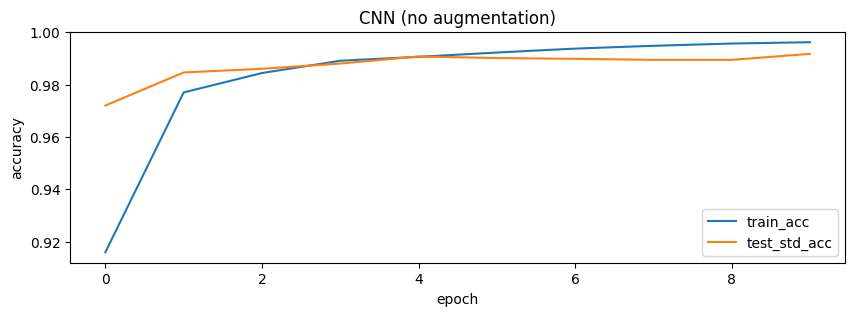

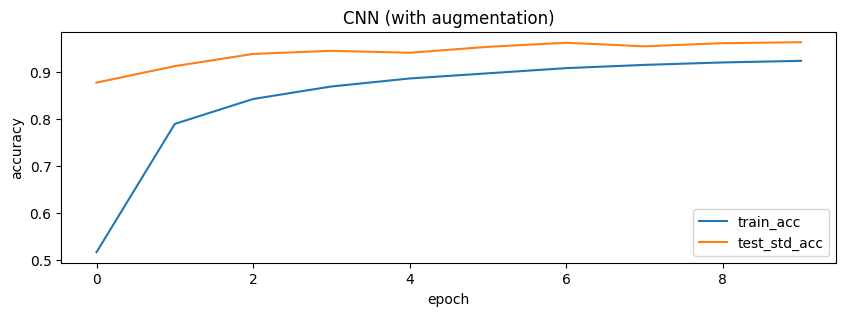

In [15]:
def plot_hist(hist, title):
    plt.figure(figsize=(10, 3))
    plt.plot(hist["train_acc"], label="train_acc")
    plt.plot(hist["val_acc"], label="test_std_acc")
    plt.title(title)
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.legend()
    plt.show()

plot_hist(hist_noaug, "CNN (no augmentation)")
plot_hist(hist_aug, "CNN (with augmentation)")


## 9) Visualizing CNN layers

We will look at:
1. **First-layer convolution filters** (weights of Conv1)
2. **Feature maps (activations)** for a single image

This helps you *see* what the CNN learns.


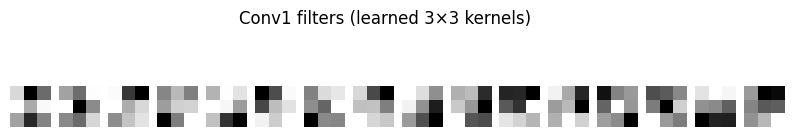

In [16]:
def show_conv1_filters(model, max_filters=16):
    conv1 = None
    for layer in model.features:
        if isinstance(layer, nn.Conv2d):
            conv1 = layer
            break
    W = conv1.weight.detach().cpu()  # (out_channels, in_channels, kH, kW)

    n = min(W.shape[0], max_filters)
    plt.figure(figsize=(10, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(W[i, 0], cmap="gray")
        plt.axis("off")
    plt.suptitle("Conv1 filters (learned 3×3 kernels)")
    plt.show()

show_conv1_filters(cnn_aug)


### Feature maps (activations)

We take **one test image**, pass it through the CNN, and visualize outputs after each convolution layer.


In [17]:
@torch.no_grad()
def get_activations(model, x):
    activations = []
    cur = x
    for layer in model.features:
        cur = layer(cur)
        if isinstance(layer, nn.Conv2d):
            activations.append(cur.detach().cpu())
    return activations

# One sample from the standard test set
img, label = test_std[0]
x = img.unsqueeze(0).to(device)

acts = get_activations(cnn_aug, x)

print("Label:", label)
print("Activation shapes:", [a.shape for a in acts])


Label: 7
Activation shapes: [torch.Size([1, 16, 28, 28]), torch.Size([1, 32, 14, 14])]


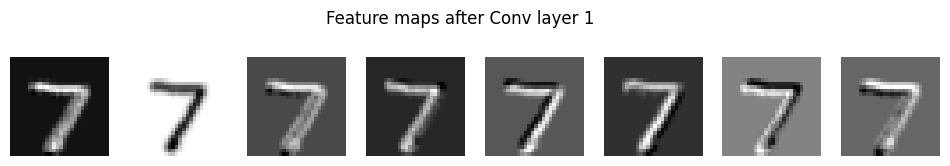

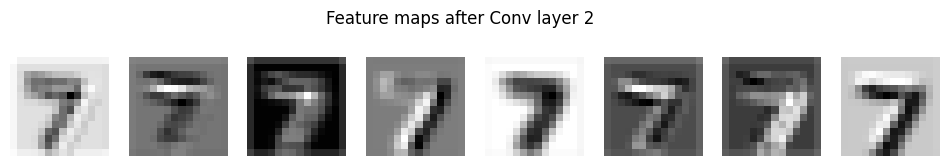

In [18]:
def show_feature_maps(activation, title, max_maps=8):
    C = activation.shape[1]
    n = min(C, max_maps)
    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(activation[0, i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()

for idx, act in enumerate(acts, start=1):
    show_feature_maps(act, f"Feature maps after Conv layer {idx}", max_maps=8)


## 10) Final reflection 

1. Compare **standard test accuracy** vs **transformed test accuracy** for both models. What do you notice?
We had
-  Baseline CNN (no augmentation)

   -  Test (standard): 0.992, starting already very high (~97%) and quickly converges to ~99%.
   -  Test (transformed): 0.997
   -  Training accuracy increases very rapidly: reaches ~99.6–99.7% within a few epochs.
   -  There is a very small gap between training and test accuracy indicating a small amount of overfitting, but overall the model generalizes well to both standard and transformed test sets.
  
-  CNN trained with augmentation

   - The training accuracy increases more slowly (~52%) due to the harder augmented samples, but it still never reaches the level of the non-augmented model (~90–92% max)
   -  Test (standard): 0.963
   -  Test (transformed): 0.922
   - So, the test accuracies remain consistently higher than training accuracy which indicates that the model is not overfitting and generalizes well to both test sets, but the overall accuracy is lower than the non-augmented model due to the increased difficulty of the augmented training data.

2. Why does augmentation help on the transformed test set?
Augmentation helps on the transformed test set because it exposes the model to a wider variety of examples during training. By including rotated and translated versions of the digits, the model learns to recognize the underlying features of the digits regardless of their orientation or position. This makes the model more robust and better able to generalize to new, unseen examples that may also be rotated or translated, which is why we see improved performance on the transformed test set.


3. Do we always expect augmentation to improve standard test accuracy? Why/why not?
Not necessarily. While augmentation can help the model generalize better to transformed examples, it may not always lead to improvements in standard test accuracy. This is because the augmented samples can introduce more variability and complexity, making it harder for the model to learn the underlying patterns. In some cases, this can result in a drop in performance on the standard test set, especially if the model becomes too focused on the augmented examples at the expense of the original ones.

**Conclusion:** In the next LAB(2), we will go deeper into CNN architectures, and you should see further accuracy improvements.


---


### 1. `RandomAffine` : principe général

`RandomAffine` est une transformation de **vision par ordinateur** qui applique, de manière aléatoire, une **transformation affine** à une image.
Une transformation affine est une combinaison linéaire de transformations géométriques qui **préservent le parallélisme**, mais pas nécessairement les distances ou les angles.

Formellement, pour un pixel de coordonnées ((x, y)), une transformation affine s’écrit :
[
\begin{pmatrix}
x' \
y'
\end{pmatrix}
=============

A
\begin{pmatrix}
x \
y
\end{pmatrix}
+
\mathbf{b}
]
où :

* (A) est une matrice (2 \times 2) (rotation, mise à l’échelle, cisaillement),
* (\mathbf{b}) est un vecteur de translation.

---

### 2. Ce que fait `RandomAffine` en pratique (PyTorch)

Dans `torchvision.transforms.RandomAffine`, PyTorch :

1. **échantillonne aléatoirement** des paramètres dans les bornes spécifiées,
2. **applique la transformation affine correspondante** à l’image,
3. répète ce processus **à chaque appel** (donc potentiellement à chaque epoch et à chaque itération).

Les paramètres principaux sont :

* `degrees` : rotation aléatoire
* `translate` : translation aléatoire (en fraction de la taille de l’image)
* `scale` : zoom avant/arrière
* `shear` : cisaillement
* `fill` : valeur des pixels créés par la transformation

---

### 3. Dans votre cas précis

Votre code :

```python
transforms.RandomAffine(degrees=35, translate=(0.3, 0.3))
```

Cela signifie que **pour chaque image MNIST** :

#### a) Rotation

* Un angle (\theta) est tiré **uniformément** dans :
  [
  \theta \sim \mathcal{U}(-35^\circ, +35^\circ)
  ]
* L’image du chiffre est donc pivotée autour de son centre.
* Cela simule :

  * chiffres légèrement penchés,
  * variations d’orientation dues à l’écriture manuscrite ou à la prise de vue.

#### b) Translation

* Un décalage horizontal et vertical est tiré aléatoirement :
  [
  \Delta x \sim \mathcal{U}(-0.3 \cdot W,; +0.3 \cdot W)
  ]
  [
  \Delta y \sim \mathcal{U}(-0.3 \cdot H,; +0.3 \cdot H)
  ]
  où (W = H = 28) pour MNIST.

Concrètement :

* Jusqu’à **±8 pixels** de déplacement horizontal et vertical,
* Le chiffre peut être décentré, partiellement proche des bords,
* Cela correspond exactement à la consigne *« digits rarely appear perfectly centered »*.

#### c) Pixels vides

* Les zones de l’image qui deviennent vides après rotation/translation sont :

  * remplies avec la valeur par défaut (`0`, donc noir pour MNIST),
  * ce qui est cohérent avec le fond du dataset.

---

### 4. Effet sur l’apprentissage (important)

#### Pour `train_aug`

* Chaque epoch voit **une version différente** des mêmes chiffres.
* Le modèle apprend des **invariances** :

  * invariance à la position,
  * invariance à l’orientation modérée.
* Cela :

  * réduit l’overfitting,
  * améliore la généralisation.

#### Pour `test_trans`

* Le modèle est évalué sur des chiffres **hors distribution stricte MNIST**,
* On mesure donc la **robustesse aux perturbations géométriques**,
* Pas seulement la performance sur des chiffres centrés.

---

### 5. Résumé synthétique (pour rapport ou soutenance)

> `RandomAffine` applique aléatoirement une transformation affine à chaque image.
> Dans notre cas, il réalise une rotation uniforme dans l’intervalle ([-35°, +35°]) et une translation allant jusqu’à 30 % de la taille de l’image.
> Cette augmentation simule des variations réalistes de position et d’orientation des chiffres manuscrits et permet d’entraîner et d’évaluer la robustesse du modèle à ces transformations.

Si vous voulez, je peux aussi vous fournir **un schéma explicatif** ou **une formulation mathématique compacte** adaptée à un rapport académique.
